# Handwritten Alphabet Recognition — Image Classification Capstone
### ML Capstone Project — Innomatics Research Labs

**Problem Type:** Multi-class Image Classification
**Target Variable:** `letter` (26 classes, `A`-`Z`)

## Step 1 — Problem Statement

**Business Objective**
Typing isn't always convenient — small devices, accessibility needs, or quick note-taking in the air without touching anything. A model that recognizes a hand-drawn letter lets a camera read handwriting drawn in mid-air instead.

**Problem Statement**
Given an image of a single handwritten letter, predict which of the 26 English alphabet letters (A-Z) it is.

**Input**
Grayscale images, each `34 x 34` pixels, showing a single white letter stroke on a black background.

**Business Use Case**
Once trained, this model is plugged into a live webcam app: a fingertip is tracked in the air, the letter you draw is captured as an image in the same style as the training data, and the model predicts which letter you wrote.

## Step 2 — Importing the Dataset

The dataset folder has one subfolder per letter (`A/`, `B/`, ... `Z/`), each containing `.jpg` images of that letter.

In [1]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from skimage.feature import hog

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)

import joblib

sns.set_style("whitegrid")
%matplotlib inline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
DATASET_DIR = "dataset"

image_paths = []
labels = []

for letter in sorted(os.listdir(DATASET_DIR)):
    letter_dir = os.path.join(DATASET_DIR, letter)
    for file_name in os.listdir(letter_dir):
        image_paths.append(os.path.join(letter_dir, file_name))
        labels.append(letter)

print("Total images found:", len(image_paths))
print("Total classes      :", len(set(labels)))

Total images found: 6831
Total classes      : 26


## Step 3 — Dataset Exploration (EDA)

In [3]:
sample_img = Image.open(image_paths[0])

print("Image size  :", sample_img.size)
print("Color mode  :", sample_img.mode, "(L = grayscale)")

Image size  : (34, 34)
Color mode  : L (L = grayscale)


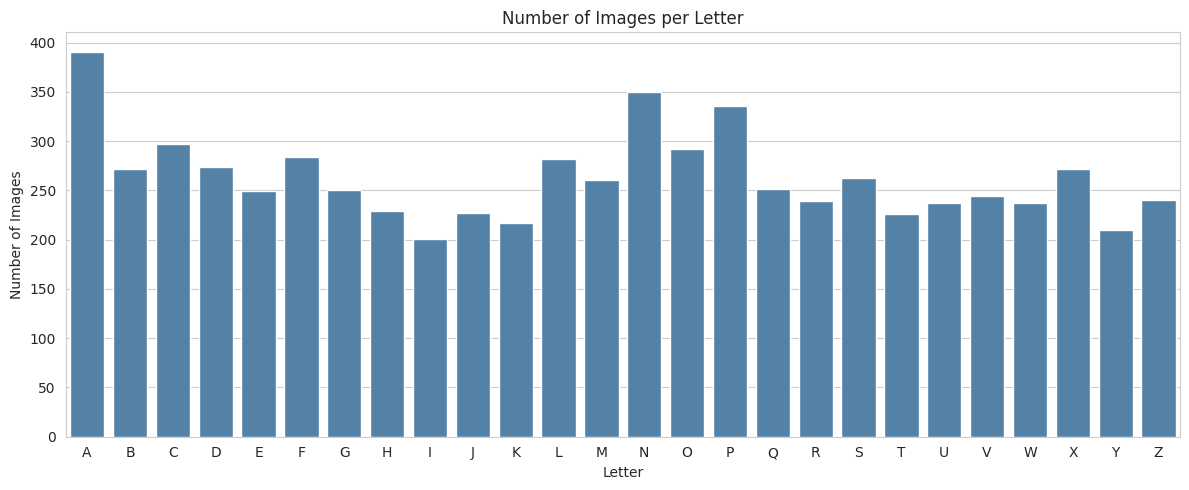

In [4]:
labels_df = pd.DataFrame({"letter": labels})
class_counts = labels_df["letter"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, color="steelblue")
plt.title("Number of Images per Letter")
plt.xlabel("Letter")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.savefig("assets/class_distribution.png")
plt.show()

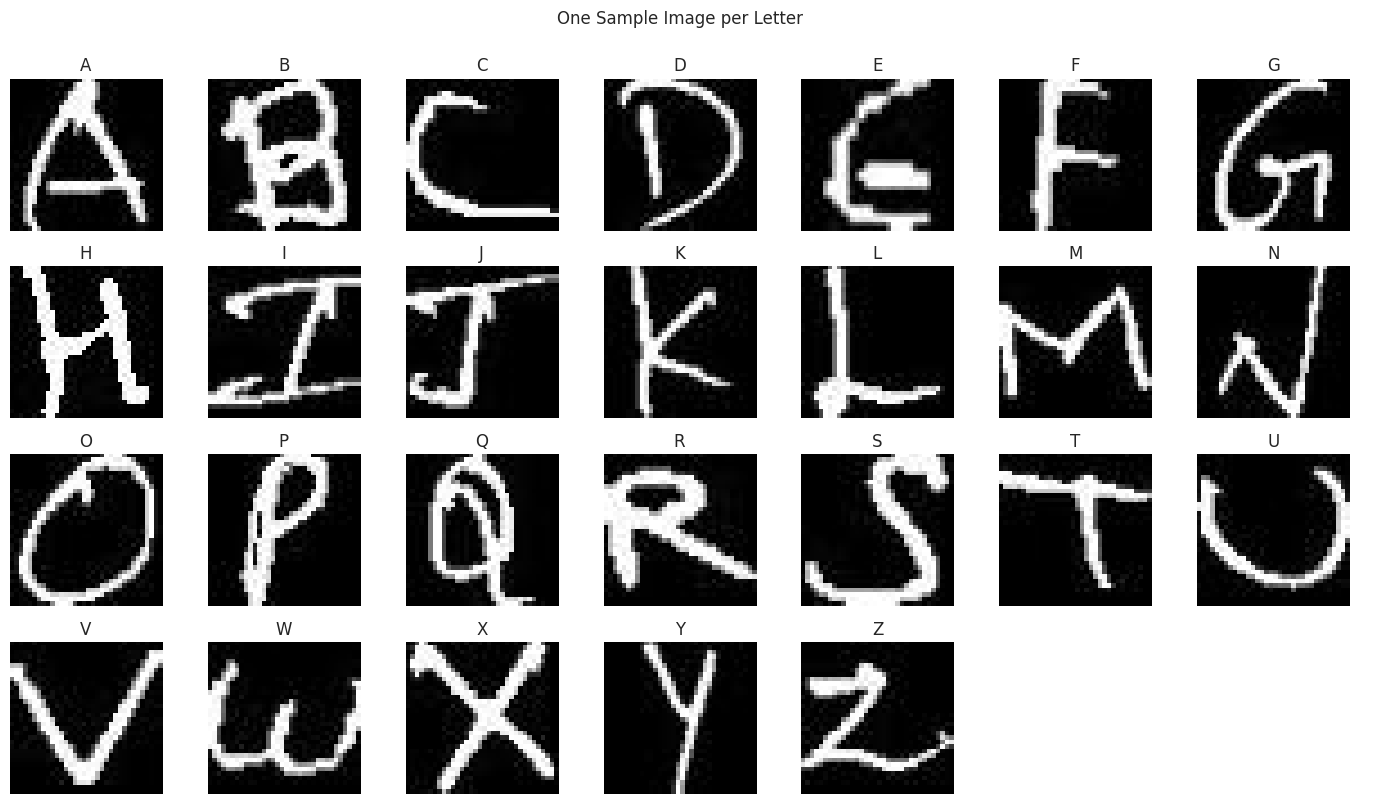

In [5]:
# One sample image per letter
fig, axes = plt.subplots(4, 7, figsize=(14, 8))
axes = axes.flatten()

letters_sorted = sorted(set(labels))
for i, letter in enumerate(letters_sorted):
    idx = labels.index(letter)
    img = Image.open(image_paths[idx])
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(letter)
    axes[i].axis("off")

for j in range(len(letters_sorted), len(axes)):
    axes[j].axis("off")

plt.suptitle("One Sample Image per Letter", y=1.0)
plt.tight_layout()
plt.savefig("assets/sample_letters.png")
plt.show()

In [6]:
# Check all images share the same size/mode, and look for corrupted files
sizes_seen = set()
modes_seen = set()
corrupted_images = []

for path in image_paths:
    try:
        img = Image.open(path)
        sizes_seen.add(img.size)
        modes_seen.add(img.mode)
    except Exception:
        corrupted_images.append(path)

print("Unique image sizes:", sizes_seen)
print("Unique color modes:", modes_seen)
print("Corrupted images  :", len(corrupted_images))

Unique image sizes: {(34, 34)}
Unique color modes: {'L'}
Corrupted images  : 0


**Observations**
- The dataset is not perfectly balanced — some letters (like `A` and `N`) have more samples than others (like `I` and `Y`) — but every class has enough images to train on.
- Every image is already `34x34` grayscale, so no resizing or color conversion is needed.
- No corrupted images were found.
- Each image shows a thin white letter stroke on a black background — this is a hand-drawn/canvas style, not a photograph, which matters later when connecting this model to a live camera app.

## Step 4 — Image Preprocessing

The only preprocessing needed is pixel normalization — scaling pixel values from `0-255` down to `0-1`.

In [7]:
sample_array = np.array(Image.open(image_paths[0]))
print("Before normalization -> min:", sample_array.min(), "max:", sample_array.max())

normalized = sample_array / 255.0
print("After normalization  -> min:", normalized.min(), "max:", normalized.max())

Before normalization -> min: 0 max: 255
After normalization  -> min: 0.0 max: 1.0


## Step 5 — Feature Extraction (HOG)

Raw pixels would give the model 34x34 = 1,156 mostly-background numbers per image. HOG (Histogram of Oriented Gradients) instead looks at the direction of the strokes, which describes the *shape* of the letter directly, giving the model fewer, more meaningful numbers to learn from.

In [8]:
def extract_features(image_path):
    img = Image.open(image_path)
    img_array = np.array(img) / 255.0

    features = hog(
        img_array,
        orientations=9,
        pixels_per_cell=(4, 4),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
    )
    return features

t0 = time.time()
X = np.array([extract_features(path) for path in image_paths])
y = np.array(labels)

print("Feature extraction took", round(time.time() - t0, 1), "seconds")
print("X shape:", X.shape)

Feature extraction took 8.8 seconds
X shape: (6831, 1764)


## Step 6 — Input-Output Separation

In [9]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes seen by the encoder:", label_encoder.classes_)

Classes seen by the encoder: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


## Step 7 — Train-Test Split

80% training, 20% testing, with `stratify=y_encoded` so every letter is represented proportionally in both sets.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded,
)

print("Training images:", X_train.shape[0])
print("Testing images :", X_test.shape[0])

Training images: 5464
Testing images : 1367


## Step 8 — Model Building (Baseline Models)

Four baseline models are trained with default settings and compared.

In [11]:
baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
}

baseline_results = []

for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    baseline_results.append({"Model": name, "Accuracy": accuracy})
    print(f"{name:22s} accuracy = {accuracy:.4f}")

Logistic Regression    accuracy = 0.9159


Decision Tree          accuracy = 0.6050


Random Forest          accuracy = 0.8895


KNN                    accuracy = 0.9232


In [12]:
baseline_df = pd.DataFrame(baseline_results).sort_values("Accuracy", ascending=False)
baseline_df

,Model,Accuracy
3,KNN,0.923189
0,Logistic Regression,0.915874
2,Random Forest,0.889539
1,Decision Tree,0.604974


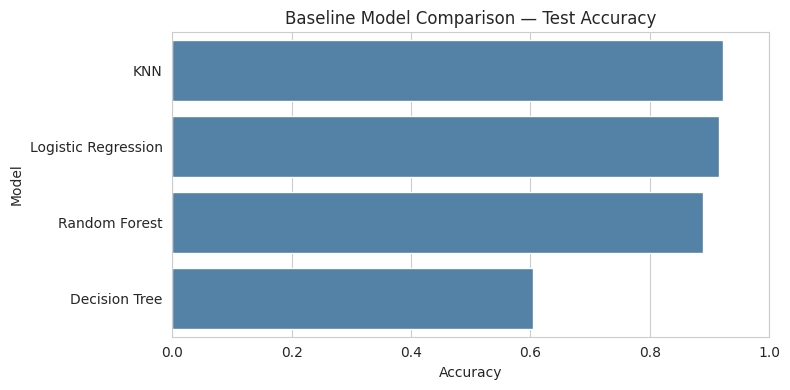

In [13]:
plt.figure(figsize=(8, 4))
sns.barplot(data=baseline_df, x="Accuracy", y="Model", color="steelblue")
plt.xlim(0, 1.0)
plt.title("Baseline Model Comparison — Test Accuracy")
plt.tight_layout()
plt.savefig("assets/model_comparison.png")
plt.show()

**Observations**
- KNN and Logistic Regression are the strongest baseline models; Random Forest and Decision Tree trail behind.
- This makes sense — HOG features describe letter *shape*, and shape-similarity is exactly what a distance-based model like KNN is good at.
- Since this app only makes one prediction per button-press (not once per video frame), KNN's slightly slower prediction speed is not a real concern here, unlike in a per-frame use case.

## Step 9 — Hyperparameter Tuning

KNN is the strongest baseline model, so it is tuned using `GridSearchCV`.

In [14]:
param_grid = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"],
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", round(grid_search.best_score_, 4))

Best Parameters: {'n_neighbors': 3, 'weights': 'distance'}
Best CV Accuracy: 0.9242


In [15]:
final_model = grid_search.best_estimator_

y_pred = final_model.predict(X_test)
tuned_accuracy = accuracy_score(y_test, y_pred)
print("Tuned Model Test Accuracy:", round(tuned_accuracy, 4))

Tuned Model Test Accuracy: 0.9217


## Step 10 — Model Evaluation

In [16]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Accuracy  : 0.9217
Precision : 0.9229
Recall    : 0.9217
F1-Score  : 0.9215


In [17]:
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

           A       0.95      0.95      0.95        78
           B       0.94      0.94      0.94        54
           C       0.89      0.98      0.94        60
           D       0.95      0.96      0.95        55
           E       0.91      0.86      0.89        50
           F       0.89      0.88      0.88        57
           G       0.96      0.92      0.94        50
           H       0.96      0.98      0.97        46
           I       0.82      0.82      0.82        40
           J       0.80      0.78      0.79        45
           K       0.86      0.86      0.86        43
           L       0.88      0.89      0.89        57
           M       0.98      0.96      0.97        52
           N       0.92      0.99      0.95        70
           O       0.85      0.93      0.89        59
           P       0.91      1.00      0.95        67
           Q       0.96      0.86      0.91        50
           R       0.91    

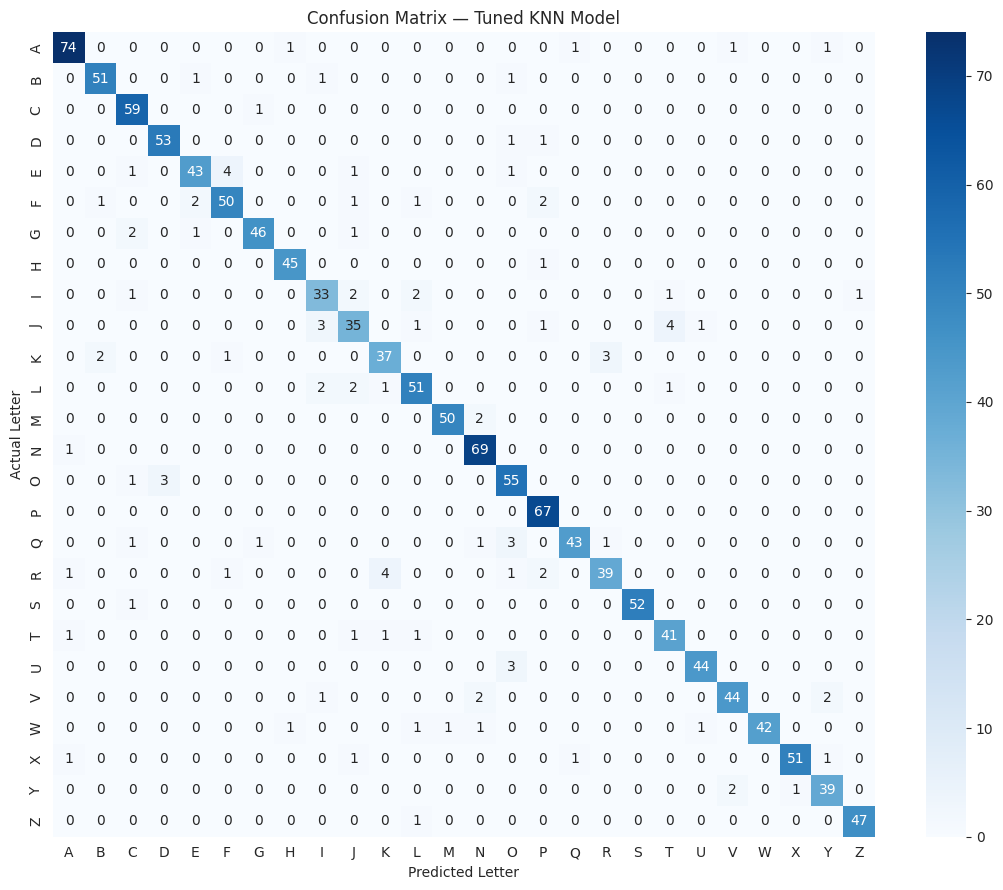

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Letter")
plt.ylabel("Actual Letter")
plt.title("Confusion Matrix — Tuned KNN Model")
plt.tight_layout()
plt.savefig("assets/confusion_matrix.png")
plt.show()

**Observations**
- The tuned KNN model reaches strong accuracy on the held-out test set.
- Most of the confusion happens between visually similar letters (for example, letters with overlapping stroke shapes), which is expected and understandable.
- This dataset is drawn strokes, not photographs, so the live camera app (Step 12) needs to *recreate* this same style rather than photograph anything — see Step 12 for how.

## Step 11 — Save Model

In [19]:
os.makedirs("models", exist_ok=True)

joblib.dump(final_model, "trained_model.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")
joblib.dump(final_model, "models/trained_model.pkl")
joblib.dump(label_encoder, "models/label_encoder.pkl")

for f in ["trained_model.pkl", "label_encoder.pkl"]:
    size_kb = os.path.getsize(f) // 1024
    print(f"Saved: {f}  ({size_kb} KB)")

Saved: trained_model.pkl  (75344 KB)
Saved: label_encoder.pkl  (0 KB)


## Step 12 — Model Loading

In [20]:
loaded_model = joblib.load("trained_model.pkl")
loaded_encoder = joblib.load("label_encoder.pkl")

sample_features = X_test[0].reshape(1, -1)
predicted_id = loaded_model.predict(sample_features)[0]
predicted_letter = loaded_encoder.inverse_transform([predicted_id])[0]
actual_letter = loaded_encoder.inverse_transform([y_test[0]])[0]

print("Predicted letter:", predicted_letter)
print("Actual letter   :", actual_letter)
print("Match:", predicted_letter == actual_letter)

Predicted letter: Z
Actual letter   : Z
Match: True


## Step 13 — Camera Integration (Air-Writing, Real-Time Recognition)

This part needs a live webcam, so it lives in its own script, `mediapipe_app.py`. Run it with:

```bash
python mediapipe_app.py
```

**What it does:**
1. Opens the webcam using OpenCV and runs MediaPipe Hands on every frame to find the hand and its landmarks.
2. Tracks the index fingertip and lets you draw a letter in the air on a virtual black canvas — the model never sees the actual camera frame, only this canvas, which keeps the image style consistent with the training data (a white stroke on a black background).
3. Press `c` to clear the canvas, `p` to predict the letter you drew, `q` to quit.
4. The canvas is resized down to `34x34` grayscale, matching the training images exactly, then passed through the same `extract_features()` HOG pipeline as Step 5.
5. `trained_model.pkl` and `label_encoder.pkl` (saved in Step 11) are loaded to predict the letter.
6. The predicted letter and confidence are drawn directly onto the video window.

See `mediapipe_app.py` for the full implementation.

## Step 14 — User Interface (Streamlit)

For a simpler, no-webcam way to try the model, `streamlit_app.py` provides a small web UI: upload a letter image, and it shows the predicted letter and confidence. Run it with:

```bash
streamlit run streamlit_app.py
```

## Step 15 — Final Conclusion

**Problem Statement**
Classify a handwritten letter image into one of 26 classes (A-Z), then bring that model into a live, camera-based air-writing recognition app.

**Dataset Summary**
- 6,831 images total across 26 letter classes (not perfectly balanced, but every class has enough samples).
- All images are `34x34` grayscale, clean and free of corrupted files.

**Approach**
- Feature extraction with HOG, which captures letter shape more efficiently than raw flattened pixels.
- Four baseline models compared (Logistic Regression, Decision Tree, Random Forest, KNN).
- KNN was tuned with GridSearchCV and selected as the final model, since it gave the best accuracy and prediction speed was not a real constraint (only one prediction per button-press, not per video frame).

**Results**
See Step 10 for exact accuracy, precision, recall, F1-score and the confusion matrix.

**Limitations**
- The training data is drawn strokes, not photographs — so the camera app must recreate a matching drawn-stroke image (via the air-writing canvas) rather than photographing anything directly, or the same domain-mismatch problem seen in earlier attempts would repeat.
- Only single-letter, static drawings are supported — no cursive or multi-letter word recognition.

**Future Scope**
- Collect a small set of real air-written samples (captured through the MediaPipe canvas itself) to fine-tune the model on data closer to actual live usage.
- Try a CNN trained directly on the raw 34x34 images and compare against the HOG + KNN pipeline.
- Extend the canvas app to recognize full words, one letter at a time.
- Deploy the Streamlit app publicly for easy demoing.